In [75]:
!pip install -q timm

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import ImageFile, Image
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from collections import Counter
import seaborn as sns

In [76]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [77]:
DATASET_PATH = Path("/kaggle/input/datasets/naumisharanyatirth/human-embryo-dataset/embryo_dataset")
ANNOT_PATH   = Path("/kaggle/input/datasets/naumisharanyatirth/human-embryo-dataset/embryo_dataset_annotations")

In [78]:
def load_dataset():
    samples = []

    for folder in DATASET_PATH.iterdir():
        if not folder.is_dir():
            continue

        csv_file = ANNOT_PATH / f"{folder.name}_phases.csv"
        if not csv_file.exists():
            print(f"Missing CSV for {folder.name}")
            continue

        df = pd.read_csv(csv_file)

        print(f"{folder.name} columns:", df.columns.tolist())

        target_col = None
        for col in df.columns:
            try:
                pd.to_numeric(df[col], errors="raise")
                target_col = col
                break
            except:
                continue

        if target_col is None:
            print(f"No numeric column in {folder.name}, skipping...")
            continue

        # Convert safely
        df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

        images = sorted(folder.glob("*.jpeg"))

        for i in range(min(len(images), len(df))):
            target = df.iloc[i][target_col]

            if pd.isna(target):
                continue

            img_path = images[i]
            samples.append((str(img_path), float(target), folder.name))

    print("Total valid samples:", len(samples))
    return samples

In [79]:
samples = load_dataset()

X = [s[0] for s in samples]   
y = [s[1] for s in samples]   
groups = [s[2] for s in samples]  

FM1017-5 columns: ['tPB2', '11', '27']
HC459-6 columns: ['tPB2', '11', '22']
GJ191-1 columns: ['tPB2', '19', '44']
LMMG218-1-10 columns: ['tPB2', '8', '17']
RD1142-2 columns: ['tPB2', '16', '35']
LS1035-1 columns: ['tPB2', '13', '30']
GS826-2 columns: ['tPB2', '6', '19']
PI1027-1 columns: ['tPB2', '15', '26']
ZS435-5 columns: ['tPB2', '9', '14']
PJ533-8 columns: ['tPNf', '23', '31']
BS596-5 columns: ['tPB2', '8', '19']
DE069-10 columns: ['tPB2', '25', '36']
AM918-2-5 columns: ['tPB2', '7', '14']
MA505-2 columns: ['tPB2', '11', '22']
MC833-6 columns: ['tPNf', '38', '46']
DE069-7 columns: ['tPB2', '13', '32']
LL854-1 columns: ['tPB2', '10', '19']
MM84-8 columns: ['tPB2', '10', '31']
DC932-2 columns: ['tPB2', '9', '17']
MA595-5 columns: ['tPB2', '14', '33']
CC007-2 columns: ['tPB2', '12', '27']
BY829-3 columns: ['tPB2', '3', '17']
BS777-8 columns: ['tPB2', '10', '27']
VC104-2 columns: ['tPB2', '13', '30']
MC663-7 columns: ['tPB2', '11', '20']
PA214-5 columns: ['tPNa', '31', '110']
LC161-1

In [80]:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1)
train_idx, temp_idx = next(gss.split(X, y, groups))

X_train = [X[i] for i in train_idx]
y_train = [y[i] for i in train_idx]

X_temp = [X[i] for i in temp_idx]
y_temp = [y[i] for i in temp_idx]
groups_temp = [groups[i] for i in temp_idx]

gss2 = GroupShuffleSplit(test_size=0.5, n_splits=1)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups_temp))

X_val = [X_temp[i] for i in val_idx]
y_val = [y_temp[i] for i in val_idx]

X_test = [X_temp[i] for i in test_idx]
y_test = [y_temp[i] for i in test_idx]

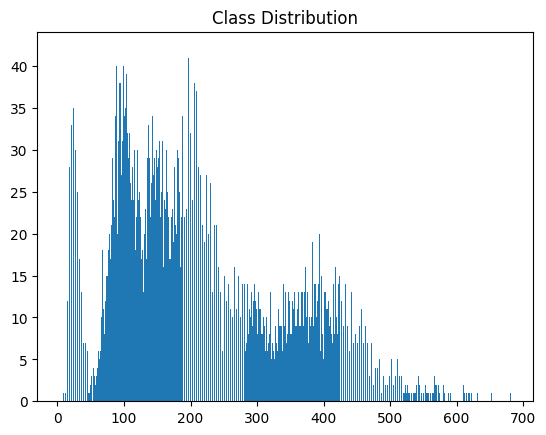

In [81]:
labels = [s[1] for s in samples]

counts = Counter(labels)

plt.bar(counts.keys(), counts.values())
plt.title("Class Distribution")
plt.show()

**AUGMENTATION**

In [82]:
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor()
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

**DATASET CLASS**

In [83]:
class EmbryoDataset(Dataset):
    def __init__(self, X, y, transform):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.X[idx]).convert("RGB")
            img = self.transform(img)
            label = self.y[idx]
            return img, label

        except Exception as e:
    
            return self.__getitem__((idx + 1) % len(self.X))

**DATALOADERS**

In [84]:
train_loader = DataLoader(EmbryoDataset(X_train, y_train, train_tf), batch_size=64, shuffle=True)
val_loader   = DataLoader(EmbryoDataset(X_val, y_val, val_tf), batch_size=64)
test_loader  = DataLoader(EmbryoDataset(X_test, y_test, val_tf), batch_size=64)

**HYBRID LOSS**

In [103]:
class HybridLoss(nn.Module):
    def __init__(self, alpha=0.7):
        super().__init__()
        self.mse = nn.MSELoss()
        self.l1 = nn.L1Loss()  # MAE
        self.alpha = alpha

    def forward(self, outputs, targets):
        outputs = outputs.squeeze()

        mse_loss = self.mse(outputs, targets)
        l1_loss = self.l1(outputs, targets)

        return self.alpha * mse_loss + (1 - self.alpha) * l1_loss

**MODEL FUNCTION**

In [104]:
def get_model(name):

    if name == "mobilenet":
        model = models.mobilenet_v2(weights="IMAGENET1K_V1")
        model.classifier[1] = nn.Linear(model.last_channel, 1)

    elif name == "vgg16":
        model = models.vgg16(weights="IMAGENET1K_V1")
        model.classifier[6] = nn.Linear(4096, 1)

    elif name == "vgg19":
        model = models.vgg19(weights="IMAGENET1K_V1")
        model.classifier[6] = nn.Linear(4096, 1)

    elif name == "inception":
        model = models.inception_v3(weights="IMAGENET1K_V1")
        model.aux_logits = False
        model.AuxLogits = None
        model.fc = nn.Linear(model.fc.in_features, 1)

    return model.to(device)

**TRAIN FUNCTION**

In [109]:
def train_two_stage(model, name):

    print(f"\nTraining {name}")

    criterion = HybridLoss()

    train_losses = []
    val_losses = []

    # Freeze all
    for param in model.parameters():
        param.requires_grad = False

    if hasattr(model, "classifier"):
        for param in model.classifier.parameters():
            param.requires_grad = True
    elif hasattr(model, "fc"):
        for param in model.fc.parameters():
            param.requires_grad = True

    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

    # Stage 1
    for epoch in range(3):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device).float()

            optimizer.zero_grad()

            out = model(x)
            if isinstance(out, tuple):
                out = out[0]

            out = out.squeeze()

            loss = criterion(out, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation loss
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device).float()

                out = model(x)
                if isinstance(out, tuple):
                    out = out[0]

                out = out.squeeze()

                loss = criterion(out, y)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Stage1 Epoch {epoch+1}: Train={avg_loss:.4f}, Val={val_loss:.4f}")

    # Unfreeze all
    for param in model.parameters():
        param.requires_grad = True

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Stage 2
    for epoch in range(5):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device).float()

            optimizer.zero_grad()

            out = model(x)
            if isinstance(out, tuple):
                out = out[0]

            out = out.squeeze()

            loss = criterion(out, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device).float()

                out = model(x)
                if isinstance(out, tuple):
                    out = out[0]

                out = out.squeeze()

                loss = criterion(out, y)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Stage2 Epoch {epoch+1}: Train={avg_loss:.4f}, Val={val_loss:.4f}")

    return model, train_losses, val_losses

In [110]:
models_dict = {}
loss_history = {}
# ["mobilenet","vgg16","vgg19","inception"]:
for name in ["mobilenet","vgg16","vgg19","inception"]:
    model = get_model(name)
    trained, train_losses, val_losses = train_two_stage(model, name)

    models_dict[name] = trained
    loss_history[name] = (train_losses, val_losses)


Training mobilenet
Stage1 Epoch 1: Train=37067.5003, Val=26096.9295
Stage1 Epoch 2: Train=24605.5891, Val=18058.8929
Stage1 Epoch 3: Train=17899.9904, Val=13820.1073
Stage2 Epoch 1: Train=13694.2498, Val=9616.2902
Stage2 Epoch 2: Train=11467.8231, Val=9325.9351
Stage2 Epoch 3: Train=10507.3144, Val=10018.3071
Stage2 Epoch 4: Train=9975.0002, Val=9742.8088
Stage2 Epoch 5: Train=9355.4803, Val=10394.9516

Training vgg16
Stage1 Epoch 1: Train=13387.1185, Val=10326.4856
Stage1 Epoch 2: Train=11871.8053, Val=10125.3805
Stage1 Epoch 3: Train=11661.4836, Val=10014.3166
Stage2 Epoch 1: Train=12384.2779, Val=10169.3178
Stage2 Epoch 2: Train=11286.9432, Val=10687.0295
Stage2 Epoch 3: Train=10960.4131, Val=10360.0232
Stage2 Epoch 4: Train=10321.0453, Val=9117.2784
Stage2 Epoch 5: Train=9964.3986, Val=10222.9151

Training vgg19
Stage1 Epoch 1: Train=13930.7325, Val=10791.0168
Stage1 Epoch 2: Train=11752.5001, Val=11170.6822
Stage1 Epoch 3: Train=11661.7217, Val=9799.5309
Stage2 Epoch 1: Train=133

**EVALUATION**

In [112]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

results = {}

for name, model in models_dict.items():
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device).float()

            out = model(x)
            if isinstance(out, tuple):
                out = out[0]

            out = out.squeeze()

            y_true.extend(y.cpu().numpy())
            y_pred.extend(out.cpu().numpy())

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    results[name] = (mae, rmse)

    print(f"{name}: MAE={mae:.4f}, RMSE={rmse:.4f}")

mobilenet: MAE=99.6863, RMSE=130.2901
vgg16: MAE=109.3622, RMSE=129.4358
vgg19: MAE=105.9929, RMSE=127.4143
inception: MAE=101.5969, RMSE=128.6238


**RESULTS**

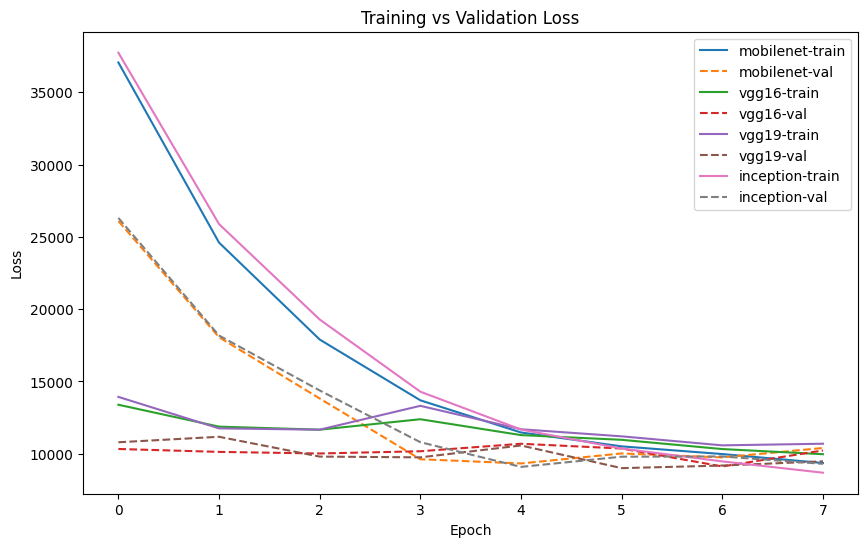

In [114]:
plt.figure(figsize=(10,6))

for name, (train_l, val_l) in loss_history.items():
    plt.plot(train_l, label=f"{name}-train")
    plt.plot(val_l, linestyle="--", label=f"{name}-val")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()